### Collect many narG variants per phylums

We can consider this for four phylums

- 1 Bacteroidota
- 2 Pseudomonadota
- 3 Bacillota
- 4 Actinomycetota

In [23]:
## First Collect taxid's for each of these 

# Read the file and find Bacteroidota taxids
bacteroidota_taxids = []
pseudomonadota_taxids = []
bacillota_taxids = []
actinomycetota_taxids = []
acidobacteriota_taxids = []
chloroflexota_taxids = []
verrucomicrobiota_taxids = []
gemmatimonadota_taxids = []
myxococcota_taxids = []

with open('../data/whole_genomes/taxids_TIGR01580_metadata.tsv', 'r') as file:
    headers = file.readline().strip().split('\t')
    
    # Find the index of 'phylum' and 'taxid' columns
    phylum_idx = headers.index('phylum')
    taxid_idx = headers.index('taxid')
    
    for line in file:
        fields = line.strip().split('\t')
        if fields[phylum_idx] == 'Bacteroidota':
            bacteroidota_taxids.append(fields[taxid_idx])
        if fields[phylum_idx] == 'Pseudomonadota':
            pseudomonadota_taxids.append(fields[taxid_idx])
        if fields[phylum_idx] == 'Bacillota':
            bacillota_taxids.append(fields[taxid_idx])
        if fields[phylum_idx] == 'Actinomycetota':
            actinomycetota_taxids.append(fields[taxid_idx])
        if fields[phylum_idx] == 'Acidobacteriota':
            acidobacteriota_taxids.append(fields[taxid_idx])
        if fields[phylum_idx] == 'Chloroflexota':
            chloroflexota_taxids.append(fields[taxid_idx])
        if fields[phylum_idx] == 'Verrucomicrobiota':
            verrucomicrobiota_taxids.append(fields[taxid_idx])
        if fields[phylum_idx] == 'Gemmatimonadota':
            gemmatimonadota_taxids.append(fields[taxid_idx])
        if fields[phylum_idx] == 'Myxococcota':
            myxococcota_taxids.append(fields[taxid_idx])

print(f"Found {len(bacteroidota_taxids)} rows with phylum Bacteroidota")
print("TaxIDs:", bacteroidota_taxids)
print(f"Found {len(pseudomonadota_taxids)} rows with phylum Pseudomonadota")
print("TaxIDs:", pseudomonadota_taxids)
print(f"Found {len(bacillota_taxids)} rows with phylum Bacillota")
print("TaxIDs:", bacillota_taxids)
print(f"Found {len(actinomycetota_taxids)} rows with phylum Actinomycetota")
print("TaxIDs:", actinomycetota_taxids)
print(f"Found {len(acidobacteriota_taxids)} rows with phylum acidobacteriota")
print("TaxIDs:", acidobacteriota_taxids)
print(f"Found {len(chloroflexota_taxids)} rows with phylum chloroflexota")
print("TaxIDs:", chloroflexota_taxids)
print(f"Found {len(verrucomicrobiota_taxids)} rows with phylum verrucomicrobiota")
print("TaxIDs:", verrucomicrobiota_taxids)
print(f"Found {len(gemmatimonadota_taxids)} rows with phylum gemmatimonadota")
print("TaxIDs:", gemmatimonadota_taxids)
print(f"Found {len(myxococcota_taxids)} rows with phylum myxococcota")
print("TaxIDs:", myxococcota_taxids)

Found 56 rows with phylum Bacteroidota
TaxIDs: ['279824', '879969', '879969', '1078087', '1078089', '1168039', '1541063', '1628158', '1629721', '1640674', '1660119', '1797313', '1797314', '1797330', '1797348', '1797365', '1869212', '1895720', '1895834', '1898104', '1940288', '1965233', '1973922', '1973925', '1973998', '1974002', '1974004', '1974008', '2010828', '2013680', '2013684', '2018083', '2021370', '2021391', '2023866', '2023870', '2024823', '2026728', '2026756', '2029867', '2030927', '2044936', '2044941', '2044944', '2049046', '2050562', '2053594', '2099675', '2202734', '2448779', '2487017', '2606637', '2652391', '2854755', '2940640', '2986998']
Found 2804 rows with phylum Pseudomonadota
TaxIDs: ['82', '87', '235', '280', '281', '287', '292', '293', '294', '298', '303', '304', '305', '306', '316', '317', '337', '477', '478', '479', '480', '488', '493', '498', '529', '536', '539', '545', '546', '548', '549', '550', '553', '554', '555', '562', '564', '569', '571', '573', '574', '5

## create fasta files for each one.



In [24]:
from Bio import SeqIO



bacteroidota_set = set(bacteroidota_taxids)
pseudomonadota_set = set(pseudomonadota_taxids)
bacillota_set = set(bacillota_taxids)
actinomycetota_set = set(actinomycetota_taxids)
acidobacteriota_set = set(acidobacteriota_taxids)
chloroflexota_set = set(chloroflexota_taxids)
verrucomicrobiota_set = set(verrucomicrobiota_taxids)
gemmatimonadota_set = set(gemmatimonadota_taxids)
myxococcota_set = set(myxococcota_taxids)

# store sequences per phylum 
bacteroidota_seqs = []
pseudomonadota_seqs = []
bacillota_seqs = []
actinomycetota_seqs = []
acidobacteriota_seqs = []
chloroflexota_seqs = []
verrucomicrobiota_seqs = []
gemmatimonadota_seqs = []
myxococcota_seqs = []


input_fasta = "../data/whole_genomes/TIGR01580.fasta"  

for record in SeqIO.parse(input_fasta, "fasta"):
    header = record.description
    if 'taxID:' in header:
        taxid = header.split('taxID:')[-1].split()[0]
        
        # Check each phylum
        if taxid in bacteroidota_set:
            bacteroidota_seqs.append(record)
        elif taxid in pseudomonadota_set:
            pseudomonadota_seqs.append(record)
        elif taxid in bacillota_set:
            bacillota_seqs.append(record)
        elif taxid in actinomycetota_set:
            actinomycetota_seqs.append(record)
        elif taxid in acidobacteriota_set:
            acidobacteriota_seqs.append(record)
        elif taxid in chloroflexota_set:
            chloroflexota_seqs.append(record)
        elif taxid in verrucomicrobiota_set:
            verrucomicrobiota_seqs.append(record)
        elif taxid in gemmatimonadota_set:
            gemmatimonadota_seqs.append(record)
        elif taxid in myxococcota_set:
            myxococcota_seqs.append(record)

# Write each phylum to separate FASTA files
SeqIO.write(bacteroidota_seqs, "../data/whole_genomes/Bacteroidota.fasta", "fasta")
SeqIO.write(pseudomonadota_seqs, "../data/whole_genomes/Pseudomonadota.fasta", "fasta")
SeqIO.write(bacillota_seqs, "../data/whole_genomes/Bacillota.fasta", "fasta")
SeqIO.write(actinomycetota_seqs, "../data/whole_genomes/Actinomycetota.fasta", "fasta")
SeqIO.write(acidobacteriota_seqs, "../data/whole_genomes/acidobacteriota.fasta", "fasta")
SeqIO.write(chloroflexota_seqs, "../data/whole_genomes/chloroflexota.fasta", "fasta")
SeqIO.write(verrucomicrobiota_seqs, "../data/whole_genomes/verrucomicrobiota.fasta", "fasta")
SeqIO.write(gemmatimonadota_seqs, "../data/whole_genomes/gemmatimonadota.fasta", "fasta")
SeqIO.write(myxococcota_seqs, "../data/whole_genomes/myxococcota.fasta", "fasta")

 
print(f"Bacteroidota: {len(bacteroidota_seqs)} sequences")
print(f"Pseudomonadota: {len(pseudomonadota_seqs)} sequences")
print(f"Bacillota: {len(bacillota_seqs)} sequences")
print(f"Actinomycetota: {len(actinomycetota_seqs)} sequences")
print(f"acidobacteriota: {len(acidobacteriota_seqs)} sequences")
print(f"chloroflexota: {len(chloroflexota_seqs)} sequences")
print(f"verrucomicrobiota: {len(verrucomicrobiota_seqs)} sequences")
print(f"gemmatimonadota: {len(gemmatimonadota_seqs)} sequences")
print(f"myxococcota: {len(myxococcota_seqs)} sequences")



Bacteroidota: 114 sequences
Pseudomonadota: 5629 sequences
Bacillota: 1029 sequences
Actinomycetota: 2225 sequences
acidobacteriota: 42 sequences
chloroflexota: 61 sequences
verrucomicrobiota: 6 sequences
gemmatimonadota: 5 sequences
myxococcota: 27 sequences


### Get 5 non-redundant sequences for each phylum. 

In [25]:
from Bio import SeqIO
import random



def get_reps(sequences, num_representatives=5):
    if len(sequences) <= num_representatives:
        return sequences
    
    sequences_by_taxid = {}
    for record in sequences:
        header = record.description
        if 'taxID:' in header:
            taxid = header.split('taxID:')[-1].split()[0]
            if taxid not in sequences_by_taxid:
                sequences_by_taxid[taxid] = []
            sequences_by_taxid[taxid].append(record)
    

    unique_taxid_seqs = []
    for taxid, seqs in sequences_by_taxid.items():
        unique_taxid_seqs.append(random.choice(seqs))  # Pick one random sequence per taxid
    

    if len(unique_taxid_seqs) >= num_representatives:
        return random.sample(unique_taxid_seqs, num_representatives)
    else:
        return random.sample(sequences, min(num_representatives, len(sequences)))


bacteroidota_reps = get_reps(bacteroidota_seqs, 5)
pseudomonadota_reps = get_reps(pseudomonadota_seqs, 5)
bacillota_reps = get_reps(bacillota_seqs, 5)
actinomycetota_reps = get_reps(actinomycetota_seqs, 5)
acidobacteriota_reps = get_reps(acidobacteriota_seqs, 5)
chloroflexota_reps = get_reps(chloroflexota_seqs, 5)
verrucomicrobiota_reps = get_reps(verrucomicrobiota_seqs, 5)
gemmatimonadota_reps = get_reps(gemmatimonadota_seqs, 5)
myxococcota_reps = get_reps(myxococcota_seqs, 5)


SeqIO.write(bacteroidota_reps, "../data/whole_genomes/Bacteroidota_representatives.fasta", "fasta")
SeqIO.write(pseudomonadota_reps, "../data/whole_genomes/Pseudomonadota_representatives.fasta", "fasta")
SeqIO.write(bacillota_reps, "../data/whole_genomes/Bacillota_representatives.fasta", "fasta")
SeqIO.write(actinomycetota_reps, "../data/whole_genomes/Actinomycetota_representatives.fasta", "fasta")
SeqIO.write(acidobacteriota_reps, "../data/whole_genomes/acidobacteriota_representatives.fasta", "fasta")
SeqIO.write(chloroflexota_reps, "../data/whole_genomes/chloroflexota_representatives.fasta", "fasta")
SeqIO.write(verrucomicrobiota_reps, "../data/whole_genomes/verrucomicrobiota_representatives.fasta", "fasta")
SeqIO.write(gemmatimonadota_reps, "../data/whole_genomes/gemmatimonadota_representatives.fasta", "fasta")
SeqIO.write(myxococcota_reps, "../data/whole_genomes/myxococcota_representatives.fasta", "fasta")



print("Representative sequences selected:")
print(f"Bacteroidota: {len(bacteroidota_reps)} representatives")
print(f"Pseudomonadota: {len(pseudomonadota_reps)} representatives")
print(f"Bacillota: {len(bacillota_reps)} representatives")
print(f"Actinomycetota: {len(actinomycetota_reps)} representatives")
print(f"acidobacteriota: {len(acidobacteriota_reps)} representatives")
print(f"chloroflexota: {len(chloroflexota_reps)} representatives")
print(f"verrucomicrobiota: {len(verrucomicrobiota_reps)} representatives")
print(f"gemmatimonadota: {len(gemmatimonadota_reps)} representatives")
print(f"myxococcota: {len(myxococcota_reps)} representatives")

Representative sequences selected:
Bacteroidota: 5 representatives
Pseudomonadota: 5 representatives
Bacillota: 5 representatives
Actinomycetota: 5 representatives
acidobacteriota: 5 representatives
chloroflexota: 5 representatives
verrucomicrobiota: 5 representatives
gemmatimonadota: 5 representatives
myxococcota: 5 representatives


### Next, blast-align each of our 57 to each of these 45 and see how well it fits in each phylum. 

In [26]:
from Bio import SeqIO
from Bio import Align
from Bio.Align import substitution_matrices
import pandas as pd


query_seqs = list(SeqIO.parse("../out/aaseqs/K00370/long_complete_aa_seqs.fasta", "fasta"))


phyla = ['Bacteroidota', 'Pseudomonadota', 'Bacillota', 'Actinomycetota', 
         'acidobacteriota', 'chloroflexota', 'verrucomicrobiota', 
         'gemmatimonadota', 'myxococcota']


aligner = Align.PairwiseAligner()
aligner.substitution_matrix = substitution_matrices.load("BLOSUM62")
aligner.mode = 'global'  


results = []

print("Performing pairwise alignments...")

for query_seq in query_seqs:
    query_id = query_seq.id
    
    for phylum in phyla:
        rep_file = f"../data/whole_genomes/{phylum}_representatives.fasta"
        try:
            rep_seqs = list(SeqIO.parse(rep_file, "fasta"))
        except FileNotFoundError:
            print(f"Warning: {rep_file} not found, skipping {phylum}")
            continue
        
        for i, rep_seq in enumerate(rep_seqs):
            rep_id = rep_seq.id
            
            # Perform alignment
            alignment = aligner.align(query_seq.seq, rep_seq.seq)[0]  # Take best alignment
            
            # Calculate alignment score and identity
            score = alignment.score
            alignment_length = alignment.shape[1]
            identities = sum(a == b for a, b in zip(alignment[0], alignment[1]))
            identity_percent = (identities / alignment_length) * 100
            
            results.append({
                'query_id': query_id,
                'phylum': phylum,
                'representative_id': rep_id,
                'representative_index': i + 1,
                'alignment_score': score,
                'alignment_length': alignment_length,
                'identities': identities,
                'identity_percent': identity_percent
            })
    
    print(f"Completed alignments for query {query_id}")


df_results = pd.DataFrame(results)


df_results.to_csv("../out/whole_genomes/phylum_alignment_scores.csv", index=False)


summary_df = df_results.groupby(['query_id', 'phylum']).agg({
    'alignment_score': 'mean',
    'identity_percent': 'mean'
}).reset_index()

summary_df.to_csv("../out/whole_genomes/phylum_alignment_summary.csv", index=False)

print("Alignment completed!")
print(f"Total alignments performed: {len(results)}")
print(f"Results saved to: phylum_alignment_scores.csv")
print(f"Summary saved to: phylum_alignment_summary.csv")

# Print some statistics
print("\nAlignment statistics per phylum:")
for phylum in phyla:
    phylum_data = df_results[df_results['phylum'] == phylum]
    if len(phylum_data) > 0:
        avg_score = phylum_data['alignment_score'].mean()
        avg_identity = phylum_data['identity_percent'].mean()
        print(f"{phylum}: {len(phylum_data)} alignments, avg score: {avg_score:.2f}, avg identity: {avg_identity:.2f}%")

Performing pairwise alignments...
Completed alignments for query Soil11.scaffold_431547323_c1_2
Completed alignments for query Soil11.scaffold_587233302_c1_1
Completed alignments for query Soil11.scaffold_65427810_c1_20
Completed alignments for query Soil11.scaffold_211583530_c1_6
Completed alignments for query Soil12.scaffold_266712765_c1_2
Completed alignments for query Soil14.scaffold_576820813_c1_40
Completed alignments for query Soil14.scaffold_280216268_c1_12
Completed alignments for query Soil14.scaffold_465502786_c1_2
Completed alignments for query Soil14.scaffold_596019752_c1_119
Completed alignments for query Soil15.scaffold_116822102_c1_19
Completed alignments for query Soil15.scaffold_175810641_c1_3
Completed alignments for query Soil15.scaffold_16321085_c1_6
Completed alignments for query Soil15.scaffold_1255266399_c1_142
Completed alignments for query Soil16.scaffold_436666653_c1_2
Completed alignments for query Soil16.scaffold_804923086_c1_3
Completed alignments for quer

### Next, collect these statistics for each group

In [27]:
import numpy as np

groups = pd.read_csv("../out/groups/assignments_K00370_v2.tsv", sep = '\t', header = None).values
summary_stats = pd.read_csv("../out/whole_genomes/phylum_alignment_summary.csv")

#count group_sizes:
group_size = np.zeros(4)
for row in groups:
    if row[0][-1] == '1':
        group_size[0] += 1
    elif row[0][-1] == '2':
        group_size[1] += 1
    elif row[0][-1] == '3':
        group_size[2] += 1
    elif row[0][-1] == '4':
        group_size[3] += 1
        

group_assignments = {}

with open("../out/groups/assignments_K00370_v2.tsv", "r") as f: 
    for line in f:
        line = line.strip()
        if line:  
            parts = line.split()
            if len(parts) >= 2:
                seq_id = parts[0]
                group = int(parts[1])
                group_assignments[seq_id] = group

    
phylum_to_number = {phylum: i for i, phylum in enumerate(phyla)}

# print("Phylum to number mapping:")
# for phylum, number in phylum_to_number.items():
#     print(f"{phylum}: {number}")
    
group_phylum_scores = np.zeros((4,9))

for row in summary_stats.values:
    group_phylum_scores[group_assignments[row[0]]-1, phylum_to_number[row[1]]] += row[2]/group_size[group_assignments[row[0]]-1]
    
    

    


In [28]:
print(phylum_to_number)

{'Bacteroidota': 0, 'Pseudomonadota': 1, 'Bacillota': 2, 'Actinomycetota': 3, 'acidobacteriota': 4, 'chloroflexota': 5, 'verrucomicrobiota': 6, 'gemmatimonadota': 7, 'myxococcota': 8}


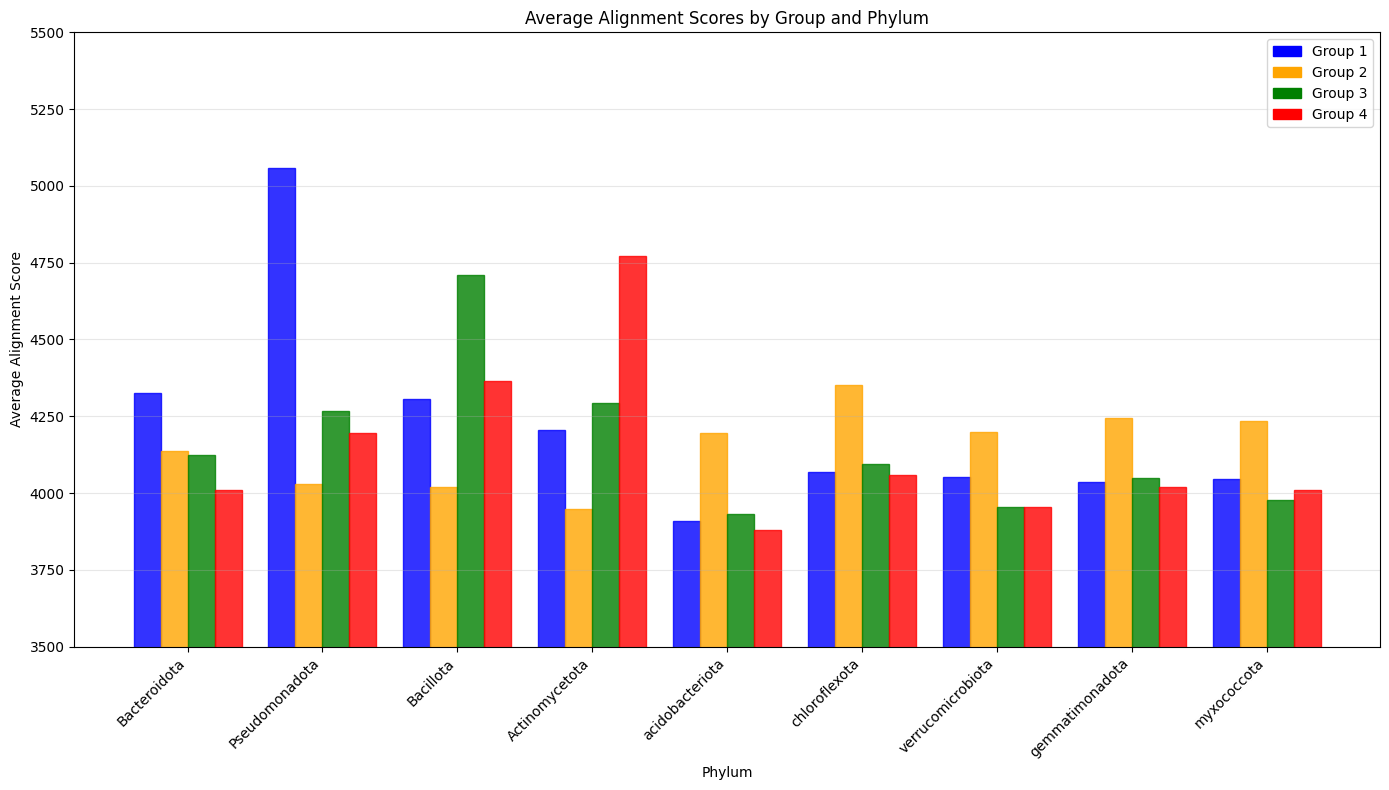

In [29]:
# Alternative: Groups clustered for each phylum
import matplotlib.pyplot as plt 


# Define colors for each group
colors = ['blue', 'orange', 'green', 'red']
group_labels = ['Group 1', 'Group 2', 'Group 3', 'Group 4']

# Set up bar positions
x = np.arange(9)  # x positions for phyla
bar_width = 0.2   # width of each bar

plt.figure(figsize=(14, 8))

for i, phylum in enumerate(phyla):
    bar_positions = [i + j * bar_width for j in range(4)]
    scores = [group_phylum_scores[group][i] for group in range(4)]
    bars = plt.bar(bar_positions, scores, width=bar_width, alpha=0.8)
    for bar, color in zip(bars, colors):
        bar.set_color(color)

plt.xlabel('Phylum')
plt.ylabel('Average Alignment Score')
plt.title('Average Alignment Scores by Group and Phylum')
plt.xticks(x + bar_width * 1.5, phyla, rotation=45, ha='right')
plt.legend([plt.Rectangle((0,0),1,1, color=color) for color in colors], group_labels)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.ylim(3500,5500)
plt.show()

### Instead of Average Alignment Score, make a histogram. 

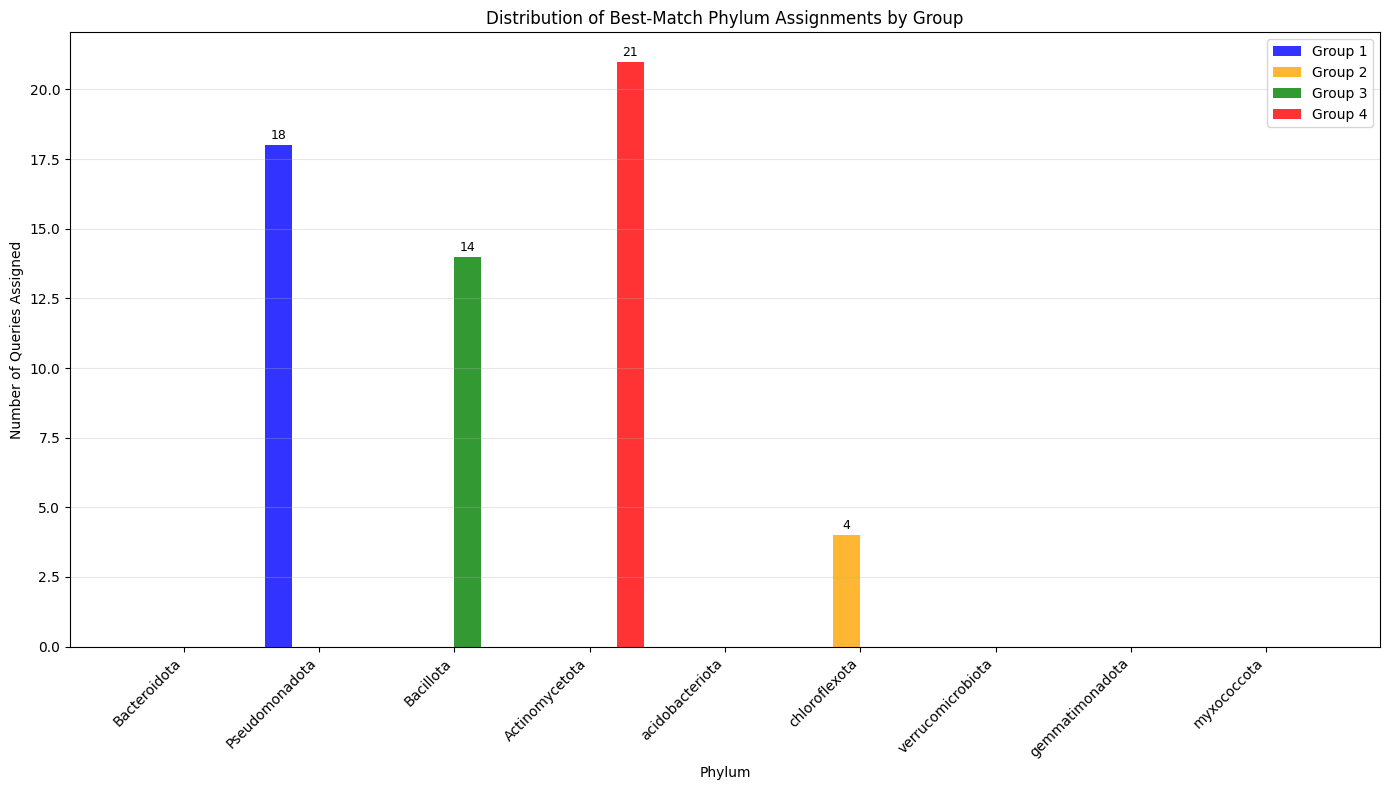

Assignment counts by phylum and group:

Bacteroidota:

Pseudomonadota:
  Group 1: 18 queries

Bacillota:
  Group 3: 14 queries

Actinomycetota:
  Group 4: 21 queries

acidobacteriota:

chloroflexota:
  Group 2: 4 queries

verrucomicrobiota:

gemmatimonadota:

myxococcota:

Total queries assigned: 57.0


In [30]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# First, let's find the "best match" phylum for each query
best_matches = {}

for row in summary_stats.values:
    query_id = row[0]
    phylum = row[1]
    score = row[2]
    
    if query_id not in best_matches:
        best_matches[query_id] = {'phylum': phylum, 'score': score}
    else:
        if score > best_matches[query_id]['score']:
            best_matches[query_id] = {'phylum': phylum, 'score': score}

# Create a matrix to count assignments
phylum_assignment_counts = np.zeros((9, 4))  # 9 phyla x 4 groups

# Count assignments
for query_id, best_match in best_matches.items():
    group = group_assignments[query_id] - 1  # Convert to 0-based index
    phylum_idx = phylum_to_number[best_match['phylum']]
    phylum_assignment_counts[phylum_idx, group] += 1

# Create the plot
plt.figure(figsize=(14, 8))

# Define colors for each group
colors = ['blue', 'orange', 'green', 'red']
group_labels = ['Group 1', 'Group 2', 'Group 3', 'Group 4']

# Set up bar positions
x = np.arange(9)  # x positions for phyla
bar_width = 0.2   # width of each bar

# Create bars for each group
for group in range(4):
    bar_positions = x + (group - 1.5) * bar_width
    plt.bar(bar_positions, phylum_assignment_counts[:, group], 
            width=bar_width, color=colors[group], label=group_labels[group], alpha=0.8)

# Customize the plot
plt.xlabel('Phylum')
plt.ylabel('Number of Queries Assigned')
plt.title('Distribution of Best-Match Phylum Assignments by Group')
plt.xticks(x, phyla, rotation=45, ha='right')
plt.legend()
plt.grid(True, alpha=0.3, axis='y')

# Add value labels on top of bars
for group in range(4):
    bar_positions = x + (group - 1.5) * bar_width
    for i, count in enumerate(phylum_assignment_counts[:, group]):
        if count > 0:  # Only label if count > 0
            plt.text(bar_positions[i], count + 0.1, f'{int(count)}', 
                    ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Print some summary statistics
print("Assignment counts by phylum and group:")
for i, phylum in enumerate(phyla):
    print(f"\n{phylum}:")
    for group in range(4):
        count = phylum_assignment_counts[i, group]
        if count > 0:
            print(f"  Group {group+1}: {int(count)} queries")

total_assignments = np.sum(phylum_assignment_counts)
print(f"\nTotal queries assigned: {total_assignments}")

In [31]:
best_matches = {}

for row in summary_stats.values:
    query_id = row[0]
    phylum = row[1]
    score = row[2]
    
    if query_id not in best_matches:
        best_matches[query_id] = {'phylum': phylum, 'score': score}
    else:
        if score > best_matches[query_id]['score']:
            best_matches[query_id] = {'phylum': phylum, 'score': score}
            

phylum_assignment_counts = np.zeros((9, 4))  # 9 phyla x 4 groups


for query_id, best_match in best_matches.items():
    group = group_assignments[query_id] - 1  
    phylum_idx = phylum_to_number[best_match['phylum']]
    phylum_assignment_counts[phylum_idx, group] += 1


for element in groups:
    print('ID: ', element[0][:-2], 'phylum match: ', 'group: ', element[0][-1], best_matches[element[0][:-2]]['phylum'])

ID:  Soil11.scaffold_431547323_c1_2 phylum match:  group:  2 chloroflexota
ID:  Soil11.scaffold_587233302_c1_1 phylum match:  group:  1 Pseudomonadota
ID:  Soil11.scaffold_65427810_c1_20 phylum match:  group:  4 Actinomycetota
ID:  Soil11.scaffold_211583530_c1_6 phylum match:  group:  1 Pseudomonadota
ID:  Soil12.scaffold_266712765_c1_2 phylum match:  group:  1 Pseudomonadota
ID:  Soil14.scaffold_576820813_c1_40 phylum match:  group:  1 Pseudomonadota
ID:  Soil14.scaffold_280216268_c1_12 phylum match:  group:  1 Pseudomonadota
ID:  Soil14.scaffold_465502786_c1_2 phylum match:  group:  4 Actinomycetota
ID:  Soil14.scaffold_596019752_c1_119 phylum match:  group:  3 Bacillota
ID:  Soil15.scaffold_116822102_c1_19 phylum match:  group:  4 Actinomycetota
ID:  Soil15.scaffold_175810641_c1_3 phylum match:  group:  3 Bacillota
ID:  Soil15.scaffold_16321085_c1_6 phylum match:  group:  1 Pseudomonadota
ID:  Soil15.scaffold_1255266399_c1_142 phylum match:  group:  3 Bacillota
ID:  Soil16.scaffold_